# EfficientNet-B0 U-Net for Food Segmentation

This notebook implements the paper-inspired optimization step after the EfficientNet-B0 baseline and the EfficientNet-B0 data augmentation experiment.

The core idea is to keep EfficientNet-B0 as an ImageNet-pretrained encoder, but replace the weak FCN-style head with a U-Net decoder. The decoder progressively upsamples high-level features and fuses them with lower-level EfficientNet feature maps through skip connections, which should help recover food boundaries and smaller regions.

The fixed 3,000/500/1,000 split is reused. Training images use the same simple augmentation strategy as the augmentation experiment. Validation mIoU selects the best checkpoint, and the official test set is evaluated once after loading that best checkpoint.


## 1. Setup and Imports

This section imports the libraries used by the EfficientNet U-Net experiment. It redirects torchvision weights into the project folder and uses `tqdm.std` so progress bars render as plain text in VS Code/Colab.


In [1]:
import json
import os
import random
from pathlib import Path

TORCH_CACHE_DIR = Path.cwd().resolve() / "Torch_Model_Cache"
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageEnhance
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.std import tqdm

print("PyTorch:", torch.__version__)
print("Torch model cache:", TORCH_CACHE_DIR)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)


Mounted at /content/drive
PyTorch: 2.11.0+cu128
Torch model cache: /content/Torch_Model_Cache
Available device: cuda


---
## 2. Fixed Values and Paths

This section defines paths and constants. It first checks the current working directory, then common Colab locations. Batch size and maximum epochs follow the previous baseline setup.


In [2]:
CANDIDATE_ROOTS = [
    Path.cwd().resolve(),
    Path("/content/drive/MyDrive/COMP9444/9444"),
    Path("/content/9444"),
]

ROOT = next(
    (
        root for root in CANDIDATE_ROOTS
        if (root / "UECFOODPIX" / "data").exists()
        and (root / "uecfoodpix_split_train3000_val500.json").exists()
    ),
    None,
)
if ROOT is None:
    searched = "\n".join(str(root) for root in CANDIDATE_ROOTS)
    raise FileNotFoundError(
        "Could not find UECFOODPIX/data and uecfoodpix_split_train3000_val500.json. "
        + "Searched:\n"
        + searched
    )

DATA_ROOT = ROOT / "UECFOODPIX" / "data"
SPLIT_FILE = ROOT / "uecfoodpix_split_train3000_val500.json"
BEST_MODEL_DIR = ROOT / "Best_Model"

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
MAX_EPOCHS = 60
SEED = 9444
NUM_WORKERS = 0

BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Split file: {SPLIT_FILE}")
print(f"Best model folder: {BEST_MODEL_DIR}")
print(f"Input size: {WIDTH} x {HEIGHT}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {MAX_EPOCHS}")


Project root: /content/drive/MyDrive/COMP9444/9444
Dataset root: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data
Split file: /content/drive/MyDrive/COMP9444/9444/uecfoodpix_split_train3000_val500.json
Best model folder: /content/drive/MyDrive/COMP9444/9444/Best_Model
Input size: 384 x 320
Batch size: 16
Max epochs: 60


---
## 3. Fixed Split

The same 3,000 training images, 500 validation images and 1,000 official test images are used. Test images are not used for model selection.


In [3]:
def load_split(split_file):
    split_data = json.loads(Path(split_file).read_text(encoding="utf-8"))
    train_ids = [str(item) for item in split_data["train_ids"]]
    val_ids = [str(item) for item in split_data["val_ids"]]

    assert len(train_ids) == split_data["train_size"]
    assert len(val_ids) == split_data["val_size"]
    assert len(train_ids) == len(set(train_ids))
    assert len(val_ids) == len(set(val_ids))
    assert not (set(train_ids) & set(val_ids))
    return train_ids, val_ids, split_data


def load_test_ids(data_root):
    return [
        item.strip()
        for item in (Path(data_root) / "test1000.txt").read_text().splitlines()
        if item.strip()
    ]


train_ids, val_ids, split_info = load_split(SPLIT_FILE)
test_ids = load_test_ids(DATA_ROOT)

print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Test images:", len(test_ids))
print("Train/validation overlap:", len(set(train_ids) & set(val_ids)))
print("Split seeds:", split_info["train_seed"], split_info["val_seed"])


Training images: 3000
Validation images: 500
Test images: 1000
Train/validation overlap: 0
Split seeds: 9444 9445


---
## 4. Dataset and Data Augmentation

The training set uses the same simple augmentation bridge from the previous experiment: synchronized horizontal flip, small rotation and random crop for image/mask pairs, plus mild color jitter for images only. Validation and test samples are only resized and normalized.


In [4]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

AUGMENTATION_CONFIG = {
    "horizontal_flip_prob": 0.5,
    "rotation_degrees": 3,
    "crop_scale_min": 0.9,
    "crop_scale_max": 1.0,
    "aspect_min": 0.95,
    "aspect_max": 1.05,
    "brightness": 0.05,
    "contrast": 0.05,
    "saturation": 0.04,
}


def load_categories(category_file):
    rows = Path(category_file).read_text(encoding="utf-8", errors="replace").splitlines()
    categories = ["background"]
    for row in rows[1:]:
        fields = row.strip().split(maxsplit=1)
        if len(fields) == 2:
            categories.append(fields[1])
    assert len(categories) == NUM_CLASSES
    return categories


def random_factor(strength):
    return 1.0 + random.uniform(-strength, strength)


def apply_color_jitter(image, config):
    image = ImageEnhance.Brightness(image).enhance(random_factor(config["brightness"]))
    image = ImageEnhance.Contrast(image).enhance(random_factor(config["contrast"]))
    image = ImageEnhance.Color(image).enhance(random_factor(config["saturation"]))
    return image


def random_resized_crop_pair(image, mask, config):
    width, height = image.size
    area = width * height
    for _ in range(10):
        target_area = area * random.uniform(config["crop_scale_min"], config["crop_scale_max"])
        aspect = random.uniform(config["aspect_min"], config["aspect_max"])
        crop_width = int(round((target_area * aspect) ** 0.5))
        crop_height = int(round((target_area / aspect) ** 0.5))
        if 0 < crop_width <= width and 0 < crop_height <= height:
            left = random.randint(0, width - crop_width)
            top = random.randint(0, height - crop_height)
            box = (left, top, left + crop_width, top + crop_height)
            return image.crop(box), mask.crop(box)
    return image, mask


def apply_train_augmentation(image, mask, config):
    if random.random() < config["horizontal_flip_prob"]:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    angle = random.uniform(-config["rotation_degrees"], config["rotation_degrees"])
    image = image.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=(0, 0, 0))
    mask = mask.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)

    image, mask = random_resized_crop_pair(image, mask, config)
    image = apply_color_jitter(image, config)
    return image, mask


class FoodSegmentationDataset(Dataset):
    def __init__(self, root, ids, split, augment, width, height, augmentation_config=None):
        self.root = Path(root)
        self.ids = list(ids)
        self.split = split
        self.augment = augment
        self.width = width
        self.height = height
        self.augmentation_config = augmentation_config or AUGMENTATION_CONFIG
        self.image_dir = self.root / "UECFoodPIX" / split / "img"
        self.mask_dir = self.root / "UECFoodPIX" / split / "mask"

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        sample_id = self.ids[index]
        image_path = self.image_dir / f"{sample_id}.jpg"
        mask_path = self.mask_dir / f"{sample_id}.png"

        with Image.open(image_path) as raw_image:
            image = raw_image.convert("RGB")
        with Image.open(mask_path) as raw_mask:
            mask = raw_mask.copy()

        if self.augment:
            image, mask = apply_train_augmentation(image, mask, self.augmentation_config)

        image = image.resize((self.width, self.height), Image.Resampling.BILINEAR)
        mask = mask.resize((self.width, self.height), Image.Resampling.NEAREST)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array.copy()).permute(2, 0, 1)
        image_tensor = (image_tensor - IMAGENET_MEAN) / IMAGENET_STD

        mask_array = np.asarray(mask)
        if mask_array.ndim == 3:
            mask_array = mask_array[..., 0]
        mask_tensor = torch.from_numpy(mask_array.astype(np.int64, copy=True)).long()
        return image_tensor, mask_tensor


categories = load_categories(DATA_ROOT / "category.txt")
train_dataset = FoodSegmentationDataset(
    DATA_ROOT, train_ids, "train", True, WIDTH, HEIGHT, AUGMENTATION_CONFIG
)
val_dataset = FoodSegmentationDataset(DATA_ROOT, val_ids, "train", False, WIDTH, HEIGHT)
test_dataset = FoodSegmentationDataset(DATA_ROOT, test_ids, "test", False, WIDTH, HEIGHT)

x_sample, y_sample = val_dataset[0]
print("Image tensor:", tuple(x_sample.shape))
print("Mask tensor:", tuple(y_sample.shape))
print("Sample mask label range:", int(y_sample.min()), "to", int(y_sample.max()))
print("Categories including background:", len(categories))
print("Augmentation config:", AUGMENTATION_CONFIG)


Image tensor: (3, 320, 384)
Mask tensor: (320, 384)
Sample mask label range: 0 to 99
Categories including background: 103
Augmentation config: {'horizontal_flip_prob': 0.5, 'rotation_degrees': 3, 'crop_scale_min': 0.9, 'crop_scale_max': 1.0, 'aspect_min': 0.95, 'aspect_max': 1.05, 'brightness': 0.05, 'contrast': 0.05, 'saturation': 0.04}


---
## 5. EfficientNet U-Net Architecture

The paper-inspired change is architectural: EfficientNet-B0 is used as the encoder, and a U-Net-style decoder restores spatial resolution through skip connections. This should improve spatial detail recovery compared with the baseline FCN head.


In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, dropout=0.0):
        super().__init__()
        self.conv = ConvBlock(in_channels + skip_channels, out_channels, dropout=dropout)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class EfficientNetB0UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True, dropout=0.2):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features

        self.center = ConvBlock(1280, 512, dropout=dropout)
        self.decoder4 = DecoderBlock(512, 112, 256, dropout=dropout)
        self.decoder3 = DecoderBlock(256, 40, 128, dropout=dropout)
        self.decoder2 = DecoderBlock(128, 24, 64, dropout=dropout)
        self.decoder1 = DecoderBlock(64, 16, 48, dropout=dropout * 0.5)
        self.final = nn.Sequential(
            ConvBlock(48, 32, dropout=dropout * 0.5),
            nn.Conv2d(32, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        features = []
        for index, layer in enumerate(self.encoder):
            x = layer(x)
            if index in {1, 2, 3, 5, 8}:
                features.append(x)

        skip1, skip2, skip3, skip4, bottleneck = features
        x = self.center(bottleneck)
        x = self.decoder4(x, skip4)
        x = self.decoder3(x, skip3)
        x = self.decoder2(x, skip2)
        x = self.decoder1(x, skip1)
        x = F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)
        return self.final(x)


model_preview = EfficientNetB0UNet(pretrained=False)
print(f"EfficientNet-B0 U-Net parameters: {sum(p.numel() for p in model_preview.parameters()):,}")
del model_preview


EfficientNet-B0 U-Net parameters: 14,991,363


---
## 6. Metrics, Loss, Plotting and Training Utilities

This section keeps the baseline reporting requirements: loss/accuracy/mIoU curves, validation confusion matrix, one test evaluation with the best checkpoint, full test confusion matrix, and best/worst 10 class heatmaps.

The loss combines cross-entropy with soft Dice loss. Cross-entropy stabilizes pixel classification, while Dice directly encourages region overlap.


In [6]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def update_confusion(confusion, prediction, target):
    prediction = prediction.detach().reshape(-1).cpu().to(torch.int64)
    target = target.detach().reshape(-1).cpu().to(torch.int64)
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + prediction[valid].clamp(0, NUM_CLASSES - 1)
    confusion += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)


def confusion_statistics(confusion):
    cm = confusion.double().cpu()
    tp = cm.diag()
    support = cm.sum(1)
    predicted = cm.sum(0)
    union = support + predicted - tp
    valid_iou = union > 0

    per_class_iou = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    per_class_iou[valid_iou] = tp[valid_iou] / union[valid_iou]
    pixel_accuracy = float(tp.sum() / cm.sum().clamp_min(1))
    mean_iou = float(per_class_iou[valid_iou].mean()) if valid_iou.any() else 0.0
    return {
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": mean_iou,
        "per_class_iou": per_class_iou,
        "support": support,
    }


def soft_dice_loss(logits, target, ignore_background=False, eps=1e-6):
    probabilities = torch.softmax(logits, dim=1)
    target_one_hot = F.one_hot(target.clamp(0, NUM_CLASSES - 1), NUM_CLASSES).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probabilities * target_one_hot).sum(dims)
    cardinality = probabilities.sum(dims) + target_one_hot.sum(dims)
    dice = (2.0 * intersection + eps) / (cardinality + eps)
    if ignore_background:
        dice = dice[1:]
    return 1.0 - dice.mean()


class CombinedSegmentationLoss(nn.Module):
    def __init__(self, dice_weight=0.4, ignore_background_in_dice=False):
        super().__init__()
        self.cross_entropy = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
        self.ignore_background_in_dice = ignore_background_in_dice

    def forward(self, logits, target):
        ce = self.cross_entropy(logits, target)
        dice = soft_dice_loss(
            logits,
            target,
            ignore_background=self.ignore_background_in_dice,
        )
        return ce + self.dice_weight * dice


def run_epoch(model, loader, loss_fn, device, optimizer=None, phase="train"):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    context = torch.enable_grad() if training else torch.no_grad()

    progress = tqdm(
        loader,
        desc=phase,
        leave=False,
        dynamic_ncols=False,
        ascii=True,
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    )
    with context:
        for images, masks in progress:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            loss = loss_fn(logits, masks)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.shape[0]
            update_confusion(confusion, logits.argmax(1), masks)

    stats = confusion_statistics(confusion)
    return total_loss / len(loader.dataset), stats, confusion


def plot_training_history(history, model_name):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Train loss")
    axes[0].plot(epochs, [row["val_loss"] for row in history], label="Validation loss")
    axes[0].set(title=f"{model_name}: Training and Validation Loss", xlabel="Epoch", ylabel="Combined loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_accuracy"] for row in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [row["val_accuracy"] for row in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [row["train_miou"] for row in history], label="Train mIoU")
    axes[1].plot(epochs, [row["val_miou"] for row in history], label="Validation mIoU")
    axes[1].set(title=f"{model_name}: Accuracy and mIoU", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def normalized_confusion(confusion):
    cm = confusion.detach().cpu().numpy().astype(np.float64)
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)


def plot_overall_confusion(confusion, title):
    normalized = normalized_confusion(confusion)
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
    ticks = np.arange(0, NUM_CLASSES, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_class_subset_heatmap(confusion, class_indices, title):
    normalized = normalized_confusion(confusion)
    subset = normalized[np.ix_(class_indices, class_indices)]
    labels = [categories[index] for index in class_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(subset, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=70, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)), labels=labels, fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def best_worst_class_indices(confusion, top_k=10):
    stats = confusion_statistics(confusion)
    per_class_iou = stats["per_class_iou"]
    support = stats["support"]
    valid = support > 0
    valid[0] = False
    valid_indices = torch.where(valid)[0]
    ordered = valid_indices[torch.argsort(per_class_iou[valid_indices])]
    worst = ordered[:top_k].tolist()
    best = torch.flip(ordered[-top_k:], dims=[0]).tolist()
    return best, worst, stats


def print_class_iou_table(title, indices, per_class_iou, support):
    print(title)
    for index in indices:
        print(f"{index:3d} {categories[index]:30s} IoU={float(per_class_iou[index]):.4f} support={int(support[index])}")


def plot_best_worst_heatmaps(confusion, model_name):
    best, worst, stats = best_worst_class_indices(confusion, top_k=10)
    print_class_iou_table("Best 10 classes by test IoU", best, stats["per_class_iou"], stats["support"])
    print_class_iou_table("Worst 10 classes by test IoU", worst, stats["per_class_iou"], stats["support"])
    plot_class_subset_heatmap(confusion, best, f"{model_name}: Best 10 classes test heatmap")
    plot_class_subset_heatmap(confusion, worst, f"{model_name}: Worst 10 classes test heatmap")


---
## 7. Train EfficientNet-B0 U-Net

This cell trains the paper-inspired model. The best checkpoint is saved whenever validation mIoU improves. After training, the best checkpoint is loaded and evaluated on the official test set once.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /content/Torch_Model_Cache/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 232MB/s]


Training EfficientNet-B0 U-Net
Config: {'learning_rate': 0.0005, 'weight_decay': 0.0001, 'dropout': 0.1, 'dice_weight': 1.0, 'ignore_background_in_dice': True, 'early_stopping_patience': 8, 'scheduler_patience': 3, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/EfficientNetB0_UNet_best_model.pt


{'epoch': 1, 'train_loss': 4.457275502522786, 'val_loss': 3.7010504722595217, 'train_accuracy': 0.4651149224175347, 'train_miou': 0.009536401267062585, 'val_accuracy': 0.529642626953125, 'val_miou': 0.009849764962936531, 'learning_rate': 0.0005}
Saved new best model: val_mIoU=0.0098


{'epoch': 2, 'train_loss': 3.371974592844645, 'val_loss': 3.1752888107299806, 'train_accuracy': 0.5518655707465278, 'train_miou': 0.010226755856052362, 'val_accuracy': 0.5662188639322917, 'val_miou': 0.01031094861084186, 'learning_rate': 0.0005}
Saved new best model: val_mIoU=0.0103


...

{'epoch': 56, 'train_loss': 1.570431803703308, 'val_loss': 2.226111499786377, 'train_accuracy': 0.8025581922743056, 'train_miou': 0.36355766476923485, 'val_accuracy': 0.7082020670572917, 'val_miou': 0.21392441184668437, 'learning_rate': 6.25e-05}


{'epoch': 57, 'train_loss': 1.5516080582936604, 'val_loss': 2.2381773777008056, 'train_accuracy': 0.8075485568576389, 'train_miou': 0.37444844580263936, 'val_accuracy': 0.7073765787760417, 'val_miou': 0.21252511301479027, 'learning_rate': 6.25e-05}


{'epoch': 58, 'train_loss': 1.5368460165659588, 'val_loss': 2.216297210693359, 'train_accuracy': 0.8134951687282986, 'train_miou': 0.3888720216927512, 'val_accuracy': 0.7117959147135416, 'val_miou': 0.21586835760878256, 'learning_rate': 6.25e-05}
Saved new best model: val_mIoU=0.2159


{'epoch': 59, 'train_loss': 1.5411988677978516, 'val_loss': 2.238322929382324, 'train_accuracy': 0.8142764051649306, 'train_miou': 0.3870712211868903, 'val_accuracy': 0.7097830891927084, 'val_miou': 0.2144130813521595, 'learning_rate': 6.25e-05}


{'epoch': 60, 'train_loss': 1.528101508140564, 'val_loss': 2.2208723239898682, 'train_accuracy': 0.8165455078125, 'train_miou': 0.39140474295753785, 'val_accuracy': 0.708176708984375, 'val_miou': 0.21366912569557822, 'learning_rate': 6.25e-05}


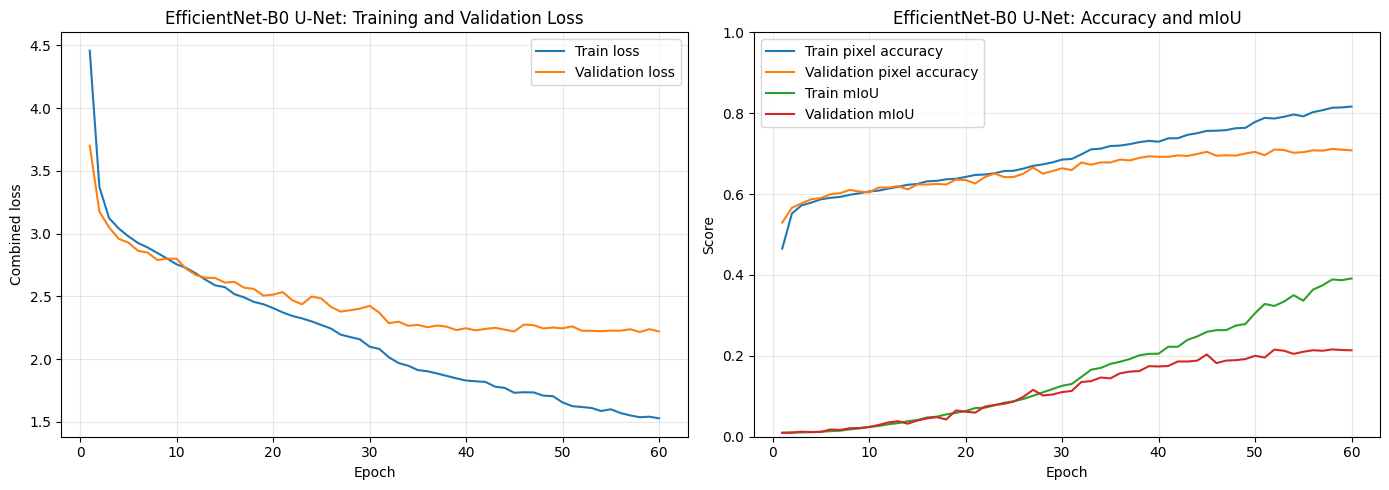

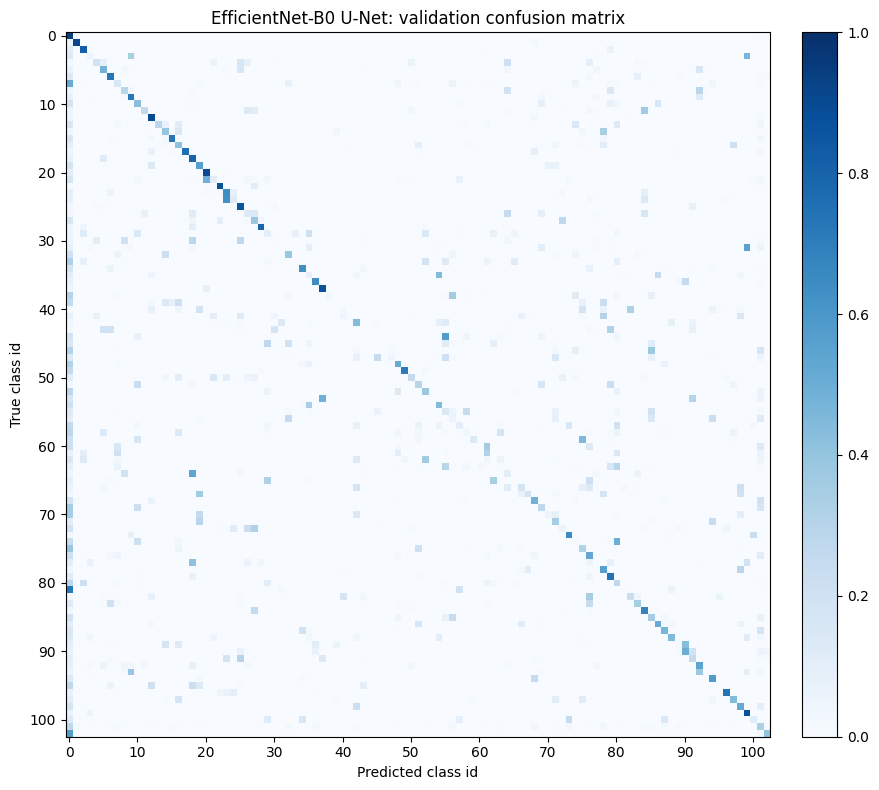

Best epoch: 58
Best validation mIoU: 0.21586835760878256
Test result: {'test_loss': 2.439155723571777, 'test_accuracy': 0.7060494303385416, 'test_miou': 0.226333535770311}


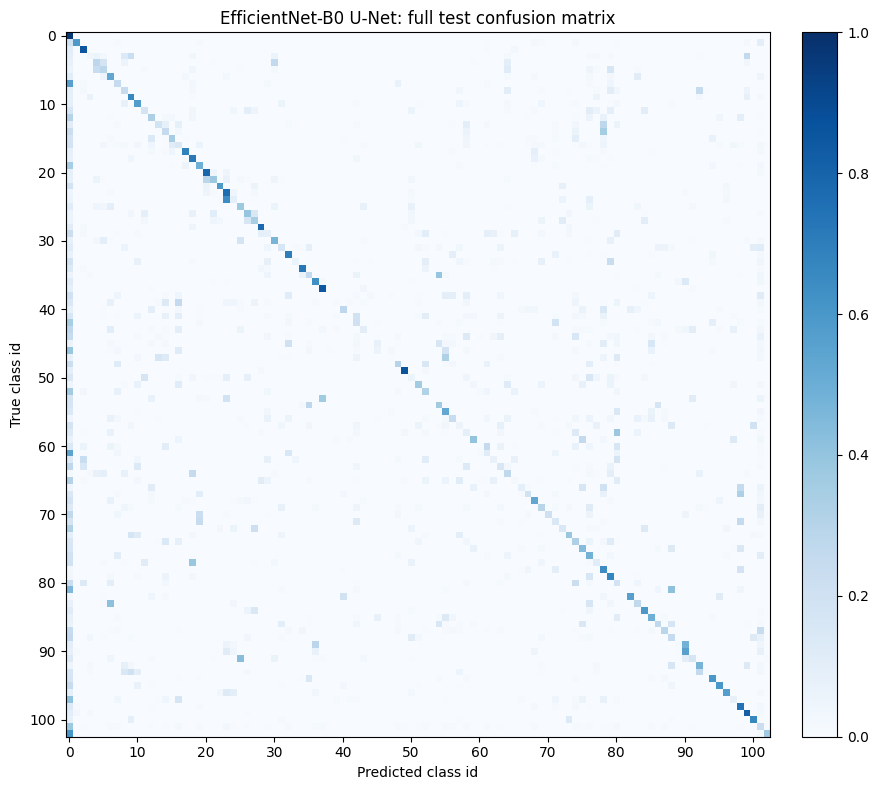

Best 10 classes by test IoU
 28 Japanese-style pancake         IoU=0.6531 support=1096639
 37 potage                         IoU=0.6310 support=470193
 17 hamburger                      IoU=0.6188 support=1081756
 34 sauteed spinach                IoU=0.5728 support=507888
 20 udon noodle                    IoU=0.5723 support=713089
 49 grilled pacific saury          IoU=0.5568 support=300532
 36 miso soup                      IoU=0.5389 support=1473637
  1 rice                           IoU=0.5232 support=927350
 82 omelet with fried rice         IoU=0.5044 support=309661
 22 soba noodle                    IoU=0.5025 support=648752
Worst 10 classes by test IoU
 41 ganmodoki                      IoU=0.0000 support=541487
 46 grilled salmon                 IoU=0.0000 support=150614
 53 steamed egg hotchpotch         IoU=0.0001 support=127838
 44 teriyaki grilled fish          IoU=0.0001 support=171224
 81 steamed meat dumpling          IoU=0.0011 support=403905
 38 sausage              

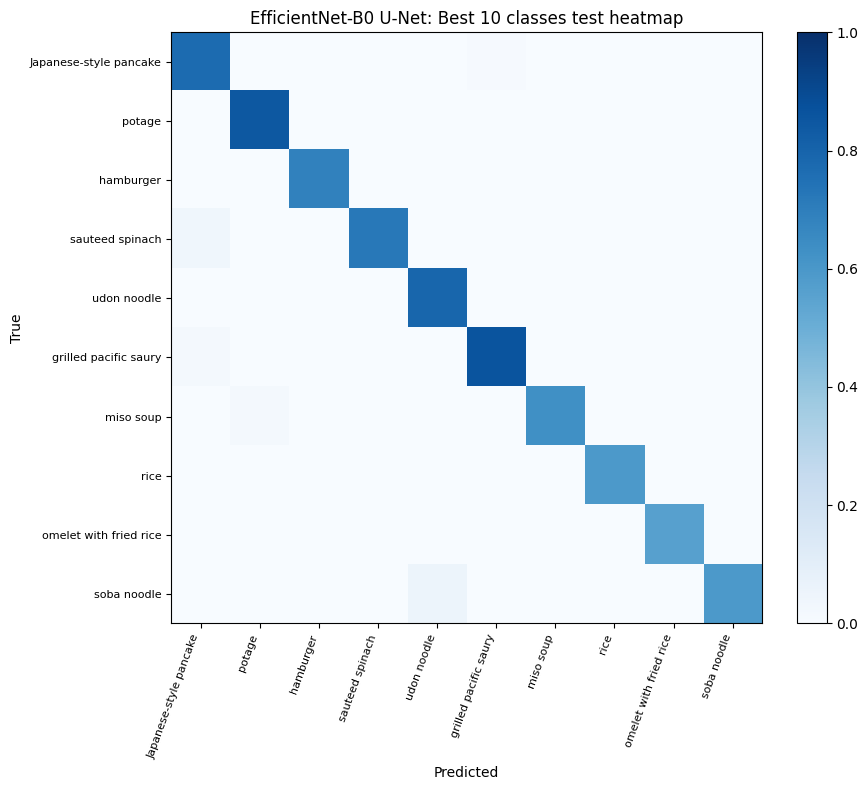

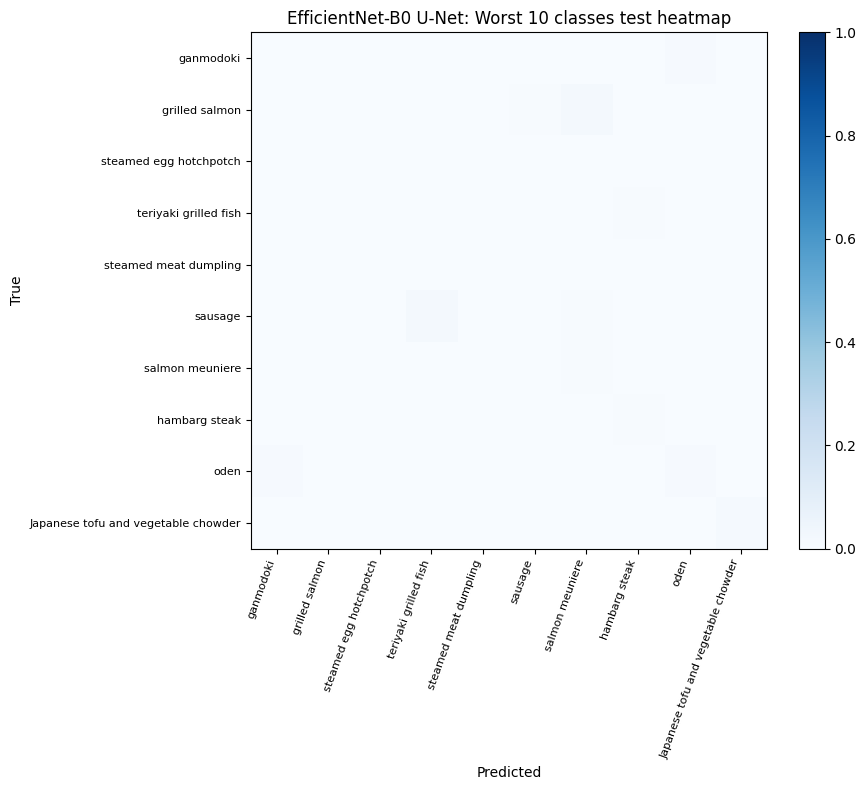

In [7]:
EFFICIENTNET_UNET_CONFIG = {
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "dropout": 0.1,
    "dice_weight": 1.0,
    "ignore_background_in_dice": True,
    "early_stopping_patience": 8,
    "scheduler_patience": 3,
    "lr_factor": 0.5,
    "pretrained": True,
}


def train_efficientnet_unet(config):
    seed_everything(SEED)
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)
    device = get_device()
    model = EfficientNetB0UNet(
        num_classes=NUM_CLASSES,
        pretrained=config["pretrained"],
        dropout=config["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["lr_factor"],
        patience=config["scheduler_patience"],
    )
    loss_fn = CombinedSegmentationLoss(
        dice_weight=config["dice_weight"],
        ignore_background_in_dice=config["ignore_background_in_dice"],
    )
    checkpoint_path = BEST_MODEL_DIR / "EfficientNetB0_UNet_best_model.pt"

    print("Training EfficientNet-B0 U-Net")
    print(f"Config: {config}")
    print(f"Checkpoint: {checkpoint_path}")

    history = []
    best_miou = -1.0
    best_epoch = 0
    best_val_confusion = None
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_stats, _ = run_epoch(
            model,
            train_loader,
            loss_fn,
            device,
            optimizer,
            phase="EfficientNet-B0 U-Net train",
        )
        val_loss, val_stats, val_confusion = run_epoch(
            model,
            val_loader,
            loss_fn,
            device,
            phase="EfficientNet-B0 U-Net validation",
        )
        scheduler.step(val_stats["mean_iou"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_stats["pixel_accuracy"],
            "train_miou": train_stats["mean_iou"],
            "val_accuracy": val_stats["pixel_accuracy"],
            "val_miou": val_stats["mean_iou"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(row)

        if val_stats["mean_iou"] > best_miou:
            best_miou = val_stats["mean_iou"]
            best_epoch = epoch
            best_val_confusion = val_confusion.clone()
            stale_epochs = 0
            torch.save(
                {
                    "model_name": "EfficientNet-B0 U-Net",
                    "epoch": best_epoch,
                    "validation_miou": best_miou,
                    "num_classes": NUM_CLASSES,
                    "image_width": WIDTH,
                    "image_height": HEIGHT,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "augmentation_config": AUGMENTATION_CONFIG,
                    "config": config,
                    "state_dict": model.state_dict(),
                },
                checkpoint_path,
            )
            print(f"Saved new best model: val_mIoU={best_miou:.4f}")
        else:
            stale_epochs += 1
            if stale_epochs >= config["early_stopping_patience"]:
                print(
                    "Early stopping after "
                    f"{config['early_stopping_patience']} epochs without validation mIoU improvement"
                )
                break

    plot_training_history(history, "EfficientNet-B0 U-Net")
    if best_val_confusion is not None:
        plot_overall_confusion(best_val_confusion, "EfficientNet-B0 U-Net: validation confusion matrix")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    test_loss, test_stats, test_confusion = run_epoch(
        model,
        test_loader,
        loss_fn,
        device,
        phase="EfficientNet-B0 U-Net test",
    )
    test_result = {
        "test_loss": test_loss,
        "test_accuracy": test_stats["pixel_accuracy"],
        "test_miou": test_stats["mean_iou"],
    }
    print("Best epoch:", best_epoch)
    print("Best validation mIoU:", best_miou)
    print("Test result:", test_result)

    plot_overall_confusion(test_confusion, "EfficientNet-B0 U-Net: full test confusion matrix")
    plot_best_worst_heatmaps(test_confusion, "EfficientNet-B0 U-Net")

    return {
        "history": history,
        "best_epoch": best_epoch,
        "best_validation_miou": best_miou,
        "checkpoint_path": checkpoint_path,
        "test_result": test_result,
        "test_confusion": test_confusion,
    }


efficientnet_unet_result = train_efficientnet_unet(EFFICIENTNET_UNET_CONFIG)


### Result Interpretation

！！！请在此处解释分析结果！！！

When writing the analysis, compare this model against both EfficientNet-B0 baseline and EfficientNet-B0 with simple augmentation. Focus on validation/test mIoU, the train-validation gap, boundary-sensitive classes, and whether the best/worst class heatmaps show fewer systematic mistakes.


---
## 8. Summary for Report Writing

This model is the direct paper-inspired optimization: EfficientNet-B0 provides efficient pretrained feature extraction, while the U-Net decoder and skip connections recover spatial details that a plain FCN head may lose. Because the dataset is RGB food imagery rather than CT scans, the paper is used for its transferable architecture principle rather than its medical-domain preprocessing or reported CT scores.
